# E2 Padding Diagnostic
Ablates Whisper encoder padding frames to quantify how much the decoder depends on their content.
Speech frames are fixed as `z_nat[0:T_eng]`; only the padding region `[T_eng:1500]` varies.
See `docs/superpowers/specs/2026-05-22-padding-diagnostic-notebook-design.md`.

In [1]:
# Cell 1 — Imports + config
import json, os, re, random
from pathlib import Path

import numpy as np
import torch
import jiwer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

# ── paths ─────────────────────────────────────────────────────────────────────
ROOT          = Path("/vol/gpudata/tsv22-fyp/accent-robust-asr")
MAPPING_PATH  = ROOT / "src/analysis/cache/utterance_mapping.json"
TEST_DATA_DIR = Path(os.environ.get("TEST_DATA_DIR",
                     "/vol/gpudata/tsv22-dev_test/data/processed/test"))
OUT_DIR       = ROOT / "results/padding_diagnostic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── constants ─────────────────────────────────────────────────────────────────
ALL_L1S  = ["Arabic", "Chinese", "Hindi", "Korean", "Spanish", "Vietnamese"]
N_PER_L1 = 50
SEED     = 42
ZERO_KS  = [0, 100, 200, 400, 800]   # nat/l2 padding frames to keep before zeroing

# populated in Cell 6b after the Whisper model is loaded
z_empty_pad: np.ndarray | None = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print(f"OUT_DIR: {OUT_DIR}")

device: cuda
OUT_DIR: /vol/gpudata/tsv22-fyp/accent-robust-asr/results/padding_diagnostic


In [2]:
# Cell 2 — Load mapping, build pid->text lookup, select prompts, load encoder states

with open(MAPPING_PATH) as f:
    mapping = json.load(f)

# ── reference text: mapping_train/dev use "prompt_id"; mapping_test uses "utterance_id" ──
pid_to_text: dict[str, str] = {}
for mpath in [
    ROOT / "src/experiments/exp2_latent_diffusion_bridge/data/mapping_train.json",
    ROOT / "src/experiments/exp2_latent_diffusion_bridge/data/mapping_dev.json",
    ROOT / "src/experiments/exp2_latent_diffusion_bridge/data/mapping_test.json",
]:
    if mpath.exists():
        with open(mpath) as f:
            for item in json.load(f):
                pid = item.get("utterance_id") or item.get("prompt_id")
                if pid and "text" in item:
                    pid_to_text[pid] = item["text"]
print(f"Reference texts loaded: {len(pid_to_text)} prompt IDs")

# ── helpers ───────────────────────────────────────────────────────────────────
def _file_exists(rel_path: str) -> bool:
    """Cheap existence check — no tensor load."""
    return (TEST_DATA_DIR / rel_path).exists()

def _load_state(rel_path: str) -> np.ndarray | None:
    """Load full encoder state; only called for the 20 selected prompts."""
    p = TEST_DATA_DIR / rel_path
    if not p.exists():
        return None
    s = torch.load(p, map_location="cpu", weights_only=False)
    z = s["hidden_states"]
    return z.float().numpy() if isinstance(z, torch.Tensor) else np.array(z, dtype=np.float32)

# ── eligible prompt list (cached to avoid slow NFS scan on re-runs) ───────────
ELIGIBLE_CACHE = ROOT / "src/analysis/cache/padding_diagnostic_eligible.json"
if ELIGIBLE_CACHE.exists():
    with open(ELIGIBLE_CACHE) as f:
        eligible = json.load(f)
    print(f"Eligible prompts loaded from cache: {len(eligible)}")
else:
    print("Building eligible list (file-existence scan, runs once) ...")
    eligible = []
    for pid, l1d in tqdm(mapping.items(), desc="Scanning prompts for eligibility"):
        eng = l1d.get("English")
        if not eng or not eng.get("speech_end_frame"):
            continue
        if not all(l in l1d and l1d[l].get("speech_end_frame") for l in ALL_L1S):
            continue
        if any(not _file_exists(l1d[l]["path"]) for l in ALL_L1S + ["English"]):
            continue
        eligible.append(pid)
    ELIGIBLE_CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(ELIGIBLE_CACHE, "w") as f:
        json.dump(eligible, f)
    print(f"Eligible prompts: {len(eligible)}  (cached to {ELIGIBLE_CACHE.name})")

# ── select 20 prompts and load their encoder states ───────────────────────────
rng = random.Random(SEED)
selected_pids = sorted(rng.sample(eligible, N_PER_L1))
print(f"Selected: {len(selected_pids)} prompts")

states: dict[str, dict] = {}
for pid in tqdm(selected_pids, desc="Loading encoder states"):
    states[pid] = {}
    for l1 in ALL_L1S + ["English"]:
        info = mapping[pid][l1]
        states[pid][l1] = {
            "z":          _load_state(info["path"]),
            "speech_end": info["speech_end_frame"],
            "speaker":    info["speaker"],
        }

print(f"Loaded {len(selected_pids)*(len(ALL_L1S)+1)} encoder states  "
      f"shape={states[selected_pids[0]]['English']['z'].shape}")

missing_text = [p for p in selected_pids if p not in pid_to_text]
if missing_text:
    print(f"WARNING: no reference text for {len(missing_text)} prompts: {missing_text[:5]}")
else:
    print("Reference text available for all selected prompts \u2713")

Reference texts loaded: 1132 prompt IDs
Eligible prompts loaded from cache: 1006
Selected: 50 prompts


Loading encoder states: 100%|██████████| 50/50 [00:02<00:00, 17.11it/s]

Loaded 350 encoder states  shape=(1500, 768)
Reference text available for all selected prompts ✓


In [3]:
# Cell 3 — Build diff-utt pairs (shuffle within L1, seed=42)
# diff_utt_partner[(pid, l1)] = a different pid from the same L1 group

diff_utt_partner: dict[tuple, str] = {}
for l1 in ALL_L1S:
    shuffled = list(selected_pids)
    random.Random(SEED).shuffle(shuffled)
    for i, pid in enumerate(shuffled):
        diff_utt_partner[(pid, l1)] = shuffled[(i + 1) % len(shuffled)]

assert all(pid != partner for (pid, _), partner in diff_utt_partner.items()), \
    "Some utterance paired with itself!"
print(f"diff_utt pairs built: {len(diff_utt_partner)}")
ex_pid, ex_l1 = selected_pids[0], ALL_L1S[0]
print(f"  e.g. ({ex_pid}, {ex_l1}) -> partner: {diff_utt_partner[(ex_pid, ex_l1)]}")

diff_utt pairs built: 300
  e.g. (arctic_a0037, Arabic) -> partner: arctic_b0304


In [4]:
# Cell 4 — Condition construction helpers

def make_padded(speech: np.ndarray, padding_src: np.ndarray,
                T_pad_start: int) -> np.ndarray:
    """
    speech:      [T_speech, 768]  fixed speech block (nat or l2)
    padding_src: [1500, 768]      source for the tail
    T_pad_start: int              frame index in padding_src where silence begins
    returns:     [1500, 768]      float32

    Clips padding_src[T_pad_start:] to exactly (1500 - T_speech) frames,
    repeating the last frame if the source is too short.
    """
    need = 1500 - len(speech)
    raw  = padding_src[T_pad_start:]
    if len(raw) == 0:
        raw = np.zeros((need, speech.shape[-1]), dtype=np.float32)
    elif len(raw) < need:
        raw = np.vstack([raw, np.tile(raw[-1:], (need - len(raw), 1))])
    else:
        raw = raw[:need]
    return np.vstack([speech, raw]).astype(np.float32)


def make_zero_k(speech: np.ndarray, padding: np.ndarray, k: int) -> np.ndarray:
    """
    Keep first k frames of padding, zero the rest.
    k=0              → pure zero tail
    k >= len(padding) → same as speech + full padding (equivalent to make_padded)
    Works for both nat and l2 speech/padding blocks.
    """
    need = 1500 - len(speech)
    pad  = np.zeros((need, speech.shape[-1]), dtype=np.float32)
    keep = min(k, need, len(padding))
    if keep > 0:
        pad[:keep] = padding[:keep]
    return np.vstack([speech, pad]).astype(np.float32)


def build_conditions(pid: str, l1: str) -> dict[str, np.ndarray]:
    """
    Returns condition arrays for one (pid, l1) pair.
    Each value is [1500, 768] float32, structured as [speech_block | padding_block].

    The speech block is taken up to the speaker's speech_end frame; the padding block
    fills the remaining frames to 1500 using make_padded (clips or repeats-last-frame
    to fit exactly). Interpolated tails are always sized to match their speech block's
    need = 1500 - T_speech before averaging.

    ── NAT-base conditions  (speech = z_nat[:T_eng], need = 1500 - T_eng) ──────────────

    "nat+nat":
        Gold reference. Speech and padding both from the native (English) recording of
        this utterance. The only condition with zero boundary discontinuity.
        layout: [z_nat[:T_eng]  |  z_nat[T_eng:1500]]

    "nat+nat_diff_utt":
        Speech from this native utterance; padding from a *different* native utterance
        (partner selected by seeded shuffle within the selected pool — never paired with
        itself). Tests whether the decoder is sensitive to utterance-specific padding
        content vs. just native-style silence.
        layout: [z_nat[:T_eng]  |  z_nat_other[T_eng_other:], clipped/padded to fill need]

    "nat+l2_same":
        Speech from the native recording; padding swapped for the L2 (accented) recording
        of the *same* utterance, starting from T_l2. Isolates the effect of accented tail
        content while the speech block is held fixed and native.
        layout: [z_nat[:T_eng]  |  z_acc[T_l2:], clipped/padded to fill need]

    "nat+interp":
        Speech from the native recording; padding = element-wise 0.5*nat_tail +
        0.5*l2_tail, where both tails are first sized to fill need via make_padded.
        A linear midpoint probe between nat+nat and nat+l2_same.
        layout: [z_nat[:T_eng]  |  0.5*(z_nat[T_eng:]+) + 0.5*(z_acc[T_l2:]+)]

    "nat+noise":
        Speech from the native recording; padding = Gaussian noise whose per-dimension
        mean and std are matched to this utterance's own native padding region
        (np.random.RandomState(SEED)). Destroys all structured information in the tail
        while preserving first- and second-order statistics.
        layout: [z_nat[:T_eng]  |  N(nat_pad_mean, nat_pad_std), shape (need, 768)]

    "nat+zero_{k}"  for k in ZERO_KS:
        Speech from the native recording; first k frames of the native padding kept
        verbatim, all remaining frames set to exactly zero.
        k=0 → entirely zero tail; k ≥ need → equivalent to nat+nat.
        Sweeps a threshold to find the minimum native-padding prefix the decoder needs.
        layout: [z_nat[:T_eng]  |  z_nat[T_eng:T_eng+k]  |  zeros(need-k)]

    "nat+empty_pad"  (included only when global z_empty_pad is not None):
        Speech from the native recording; padding replaced with the pre-computed
        empty-input encoder state — the Whisper encoder's output for an all-zero mel
        spectrogram. This is structured silence: not utterance-specific, not pure noise,
        but the encoder's learned 'nothing here' representation.
        layout: [z_nat[:T_eng]  |  z_empty_pad[T_eng:1500]]

    ── L2-base conditions  (speech = z_acc[:T_l2], need = 1500 - T_l2) ────────────────

    "l2+l2":
        Gold reference for the L2 side. Speech and padding both from the accented
        recording of this utterance — the full, unmodified L2 encoder state.
        layout: [z_acc[:T_l2]  |  z_acc[T_l2:1500]]

    "l2+l2_diff_utt":
        Speech from this L2 recording; padding from a *different* L2 recording of the
        same accent (reuses diff_utt_partner pid, but looks up the l1 key). Tests
        utterance-specificity of accented padding content.
        layout: [z_acc[:T_l2]  |  z_acc_other[T_l2_other:], clipped/padded to fill need]

    "l2+nat_same":
        Speech from the L2 recording; padding replaced with native padding from the
        same utterance, starting from T_eng. The mirror of nat+l2_same — isolates the
        effect of native padding on an accented speech block.
        layout: [z_acc[:T_l2]  |  z_nat[T_eng:], clipped/padded to fill need]

    "l2+interp":
        Speech from the L2 recording; padding = 0.5*l2_tail + 0.5*nat_tail, both
        sized to fill need = 1500 - T_l2.
        layout: [z_acc[:T_l2]  |  0.5*(z_acc[T_l2:]+) + 0.5*(z_nat[T_eng:]+)]

    "l2+noise":
        Speech from the L2 recording; padding = Gaussian noise matched to this
        utterance's L2 padding statistics (same seed=SEED as nat+noise, so noise
        realizations are paired for direct comparison).
        layout: [z_acc[:T_l2]  |  N(l2_pad_mean, l2_pad_std), shape (need, 768)]

    "l2+zero_{k}"  for k in ZERO_KS:
        Speech from the L2 recording; first k frames of L2 padding kept, rest zeroed.
        layout: [z_acc[:T_l2]  |  z_acc[T_l2:T_l2+k]  |  zeros(need-k)]

    "l2+empty_pad"  (included only when global z_empty_pad is not None):
        Speech from the L2 recording; padding from the empty-input encoder state.
        layout: [z_acc[:T_l2]  |  z_empty_pad[T_l2:1500]]
    """
    eng          = states[pid]["English"]
    l2           = states[pid][l1]
    T_eng, T_l2  = eng["speech_end"], l2["speech_end"]
    z_nat, z_acc = eng["z"], l2["z"]
    speech       = z_nat[:T_eng]
    nat_pad      = z_nat[T_eng:]
    l2_speech    = z_acc[:T_l2]
    l2_pad       = z_acc[T_l2:]

    partner_pid = diff_utt_partner[(pid, l1)]
    z_nat_other = states[partner_pid]["English"]["z"]
    T_eng_other = states[partner_pid]["English"]["speech_end"]
    z_acc_other = states[partner_pid][l1]["z"]
    T_l2_other  = states[partner_pid][l1]["speech_end"]

    # ── nat padding noise (matched mean/std, seed reproducible) ───────────────
    _nat_mean = nat_pad.mean(axis=0, keepdims=True) if len(nat_pad) else np.zeros((1, z_nat.shape[-1]), dtype=np.float32)
    _nat_std  = (nat_pad.std(axis=0, keepdims=True) + 1e-6) if len(nat_pad) else np.ones((1, z_nat.shape[-1]), dtype=np.float32)
    noise_nat = (np.random.RandomState(SEED)
                 .randn(1500 - T_eng, z_nat.shape[-1])
                 .astype(np.float32)) * _nat_std + _nat_mean

    # ── l2 padding noise ───────────────────────────────────────────────────────
    _l2_mean = l2_pad.mean(axis=0, keepdims=True) if len(l2_pad) else np.zeros((1, z_acc.shape[-1]), dtype=np.float32)
    _l2_std  = (l2_pad.std(axis=0, keepdims=True) + 1e-6) if len(l2_pad) else np.ones((1, z_acc.shape[-1]), dtype=np.float32)
    noise_l2 = (np.random.RandomState(SEED)
                .randn(1500 - T_l2, z_acc.shape[-1])
                .astype(np.float32)) * _l2_std + _l2_mean

    # ── interpolated tails: sized to the respective speech block's need ────────
    nat_tail_nat = make_padded(speech,    z_nat, T_eng)[T_eng:]   # shape: (1500-T_eng, 768)
    l2_tail_nat  = make_padded(speech,    z_acc, T_l2)[T_eng:]    # shape: (1500-T_eng, 768)
    interp_nat   = (0.5 * nat_tail_nat + 0.5 * l2_tail_nat).astype(np.float32)

    l2_tail_l2   = make_padded(l2_speech, z_acc, T_l2)[T_l2:]    # shape: (1500-T_l2, 768)
    nat_tail_l2  = make_padded(l2_speech, z_nat, T_eng)[T_l2:]   # shape: (1500-T_l2, 768)
    interp_l2    = (0.5 * l2_tail_l2 + 0.5 * nat_tail_l2).astype(np.float32)

    conds: dict[str, np.ndarray] = {
        # ── nat-base ──────────────────────────────────────────────────────────
        "nat+nat":          make_padded(speech, z_nat,       T_eng),
        "nat+nat_diff_utt": make_padded(speech, z_nat_other, T_eng_other),
        "nat+l2_same":      make_padded(speech, z_acc,       T_l2),
        "nat+interp":       np.vstack([speech, interp_nat]).astype(np.float32),
        "nat+noise":        np.vstack([speech, noise_nat]).astype(np.float32),
        # ── l2-base ───────────────────────────────────────────────────────────
        "l2+l2":            make_padded(l2_speech, z_acc,       T_l2),
        "l2+l2_diff_utt":   make_padded(l2_speech, z_acc_other, T_l2_other),
        "l2+nat_same":      make_padded(l2_speech, z_nat,       T_eng),
        "l2+interp":        np.vstack([l2_speech, interp_l2]).astype(np.float32),
        "l2+noise":         np.vstack([l2_speech, noise_l2]).astype(np.float32),
    }
    for k in ZERO_KS:
        conds[f"nat+zero_{k}"] = make_zero_k(speech,    nat_pad, k)
        conds[f"l2+zero_{k}"]  = make_zero_k(l2_speech, l2_pad,  k)

    # empty-padding conditions: requires z_empty_pad to be computed in Cell 6b
    if z_empty_pad is not None:
        conds["nat+empty_pad"] = np.vstack([speech,    z_empty_pad[T_eng:1500]]).astype(np.float32)
        conds["l2+empty_pad"]  = np.vstack([l2_speech, z_empty_pad[T_l2:1500]]).astype(np.float32)

    return conds

In [5]:
# Cell 5 — Smoke test: build conditions for one utterance, verify shapes
test_pid, test_l1 = selected_pids[0], ALL_L1S[0]
test_conds = build_conditions(test_pid, test_l1)
print(f"Conditions for ({test_pid}, {test_l1})  T_eng={states[test_pid]['English']['speech_end']}:")
for name, z in test_conds.items():
    assert z.shape == (1500, 768), f"Bad shape for {name}: {z.shape}"
    assert z.dtype == np.float32,  f"Bad dtype for {name}: {z.dtype}"
    print(f"  {name:25s}  shape={z.shape}  dtype={z.dtype}")
print("All shapes OK ✓")

Conditions for (arctic_a0037, Arabic)  T_eng=102:
  nat+nat                    shape=(1500, 768)  dtype=float32
  nat+nat_diff_utt           shape=(1500, 768)  dtype=float32
  nat+l2_same                shape=(1500, 768)  dtype=float32
  nat+interp                 shape=(1500, 768)  dtype=float32
  nat+noise                  shape=(1500, 768)  dtype=float32
  l2+l2                      shape=(1500, 768)  dtype=float32
  l2+l2_diff_utt             shape=(1500, 768)  dtype=float32
  l2+nat_same                shape=(1500, 768)  dtype=float32
  l2+interp                  shape=(1500, 768)  dtype=float32
  l2+noise                   shape=(1500, 768)  dtype=float32
  nat+zero_0                 shape=(1500, 768)  dtype=float32
  l2+zero_0                  shape=(1500, 768)  dtype=float32
  nat+zero_100               shape=(1500, 768)  dtype=float32
  l2+zero_100                shape=(1500, 768)  dtype=float32
  nat+zero_200               shape=(1500, 768)  dtype=float32
  l2+zero_200       

In [6]:
# Cell 6 — Load Whisper + decoding/WER helpers
import sys
sys.path.insert(0, str(ROOT))
from src.utils.model_loader import load_baseline_whisper

whisper_model, processor = load_baseline_whisper()
whisper_model = whisper_model.to(device).eval()
print("Whisper loaded ✓")

def _norm(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def decode_z(z: np.ndarray) -> str:
    enc = BaseModelOutput(
        last_hidden_state=torch.from_numpy(z).unsqueeze(0).to(device)
    )
    with torch.no_grad():
        ids = whisper_model.generate(
            encoder_outputs=enc,
            language="en", task="transcribe", temperature=0.0,
        )
    return processor.batch_decode(ids, skip_special_tokens=True)[0]

def utt_wer(ref: str, hyp: str) -> float | None:
    ref_n, hyp_n = _norm(ref), _norm(hyp)
    if not ref_n:
        return None
    return float(jiwer.process_words(ref_n, hyp_n).wer)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper loaded ✓


In [ ]:
# Cell 6b — Compute + cache empty-padding encoder state
# Passes an all-zero mel spectrogram through the Whisper encoder to get the
# encoder's 'nothing here' representation — structured silence with no utterance
# content. Used as a neutral padding baseline in build_conditions.

EMPTY_PAD_CACHE = OUT_DIR / "z_empty_pad.npy"

if EMPTY_PAD_CACHE.exists():
    z_empty_pad = np.load(EMPTY_PAD_CACHE)
    print(f"Loaded cached empty padding  shape={z_empty_pad.shape}")
else:
    silent_features = torch.zeros(1, 80, 3000, device=device)
    with torch.no_grad():
        enc_out = whisper_model.model.encoder(input_features=silent_features)
    z_empty_pad = enc_out.last_hidden_state[0].float().cpu().numpy()
    np.save(EMPTY_PAD_CACHE, z_empty_pad)
    print(f"Computed and cached empty padding  shape={z_empty_pad.shape}")

# quick sanity check: empty_pad conditions should now appear
_test_conds = build_conditions(selected_pids[0], ALL_L1S[0])
assert "nat+empty_pad" in _test_conds, "nat+empty_pad missing — check z_empty_pad global"
assert "l2+empty_pad"  in _test_conds, "l2+empty_pad missing — check z_empty_pad global"
assert _test_conds["nat+empty_pad"].shape == (1500, 768)
assert _test_conds["l2+empty_pad"].shape  == (1500, 768)
print("Empty-pad conditions verified ✓")
print(f"Total conditions per (pid, L1): {len(_test_conds)}")

Loaded cached empty padding  shape=(1500, 768)
Empty padding: [[-0.76290417 -2.010127   -0.33033195 ... -0.21615474 -1.0323955
  -0.2001124 ]
 [-0.12496463 -0.0469245  -0.50182134 ... -0.717465   -0.8564559
  -0.08749705]
 [-0.5847702  -0.27552152 -0.6257973  ... -1.0767988   0.19544503
  -0.05052913]
 ...
 [-0.30289677 -0.36261874 -0.32521728 ... -0.86976284  0.05901619
  -0.52400416]
 [-1.2363333  -0.2710085   0.1691838  ... -1.2236077  -0.12564036
  -0.17855603]
 [-1.7109623   0.3498522   0.62055355 ... -1.1201792  -0.5493085
  -0.096715  ]] ✓
Empty-pad conditions verified ✓
Total conditions per (pid, L1): 22


In [8]:
# Cell 7 — WER sweep (cached — re-runs load from disk if the CSV already exists)
import pandas as pd

WER_CSV = OUT_DIR / f"wer_by_condition_{len(selected_pids)}utts.csv"

if WER_CSV.exists():
    df = pd.read_csv(WER_CSV)
    print(f"Loaded cached results: {len(df)} rows ← {WER_CSV.name}")
else:
    n_conds = len(build_conditions(selected_pids[0], ALL_L1S[0]))
    n_decodes = len(selected_pids) * len(ALL_L1S) * n_conds
    print(f"Running sweep: {len(selected_pids)} utts × {len(ALL_L1S)} L1s × {n_conds} conds = {n_decodes} decodes")
    rows = []
    for pid in tqdm(selected_pids, desc="utterances"):
        ref_text = pid_to_text.get(pid, "")
        for l1 in ALL_L1S:
            conds = build_conditions(pid, l1)
            for cond_name, z in conds.items():
                hyp = decode_z(z)
                rows.append({
                    "prompt_id": pid,
                    "L1":        l1,
                    "speaker":   states[pid][l1]["speaker"],
                    "condition": cond_name,
                    "ref":       ref_text,
                    "hyp":       hyp,
                    "wer":       utt_wer(ref_text, hyp),
                })
    df = pd.DataFrame(rows)
    df.to_csv(WER_CSV, index=False)
    print(f"Saved {len(df)} rows → {WER_CSV.name}")

Running sweep: 50 utts × 6 L1s × 22 conds = 6600 decodes


utterances:   0%|          | 0/50 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'tran

Saved 6600 rows → wer_by_condition_50utts.csv


In [16]:
# Cell 8 — Summary tables: mean WER ± SEM per condition
import pandas as pd

# Full intended order — conditions absent from df (e.g. l2-base not yet run, empty_pad
# not yet computed) are silently dropped so the cell works at any stage of the sweep.
_present = set(df["condition"].unique())
COND_ORDER = [c for c in (
    ["nat+nat", "nat+nat_diff_utt", "nat+l2_same", "nat+interp", "nat+noise"]
    + [f"nat+zero_{k}" for k in ZERO_KS]
    + ["nat+empty_pad"]
    + ["l2+l2", "l2+l2_diff_utt", "l2+nat_same", "l2+interp", "l2+noise"]
    + [f"l2+zero_{k}" for k in ZERO_KS]
    + ["l2+empty_pad"]
) if c in _present]

summary = (
    df.dropna(subset=["wer"])
    .groupby("condition")["wer"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1) / len(x)**0.5, n="count")
    .reindex(COND_ORDER)
    .round(4)
)
print("=== WER by condition (all L1s) ===")
print(summary.to_string())
print()

# Per-L1 breakdown: only show conditions where L1 actually changes the result.
# nat-base conditions (except nat+l2_same and nat+interp) use a fixed English speech
# block so WER is identical across all L1s — showing them adds no information.
# l2-base conditions always vary by L1 (different speaker for each accent group).
per_l1_full = (
    df.dropna(subset=["wer"])
    .groupby(["condition", "L1"])["wer"]
    .mean()
    .unstack("L1")
)
_l1_varying = per_l1_full.index[per_l1_full.std(axis=1) > 1e-6]
per_l1 = (
    per_l1_full
    .reindex([c for c in COND_ORDER if c in _l1_varying])
    .round(4)
)
print("=== Mean WER per condition × L1  (L1-varying conditions only) ===")
print(per_l1.to_string())

summary.to_csv(OUT_DIR / "wer_summary.csv")
print(f"\nSaved wer_summary.csv ✓")

=== WER by condition (all L1s) ===
                    mean     sem    n
condition                            
nat+nat           0.0438  0.0072  300
nat+nat_diff_utt  0.0448  0.0068  300
nat+l2_same       0.0440  0.0069  300
nat+interp        0.0721  0.0095  300
nat+noise         0.7733  0.0277  300
nat+zero_0        0.0413  0.0070  300
nat+zero_100      0.0413  0.0070  300
nat+zero_200      0.0413  0.0070  300
nat+zero_400      0.0396  0.0070  300
nat+zero_800      0.0376  0.0065  300
nat+empty_pad     0.0419  0.0067  300
l2+l2             0.1668  0.0122  300
l2+l2_diff_utt    0.1711  0.0119  300
l2+nat_same       0.1637  0.0122  300
l2+interp         0.1940  0.0134  300
l2+noise          0.7368  0.0147  300
l2+zero_0         0.1743  0.0126  300
l2+zero_100       0.1749  0.0124  300
l2+zero_200       0.1747  0.0124  300
l2+zero_400       0.1780  0.0126  300
l2+zero_800       0.1691  0.0125  300
l2+empty_pad      0.1648  0.0123  300

=== Mean WER per condition × L1  (L1-varying conditi

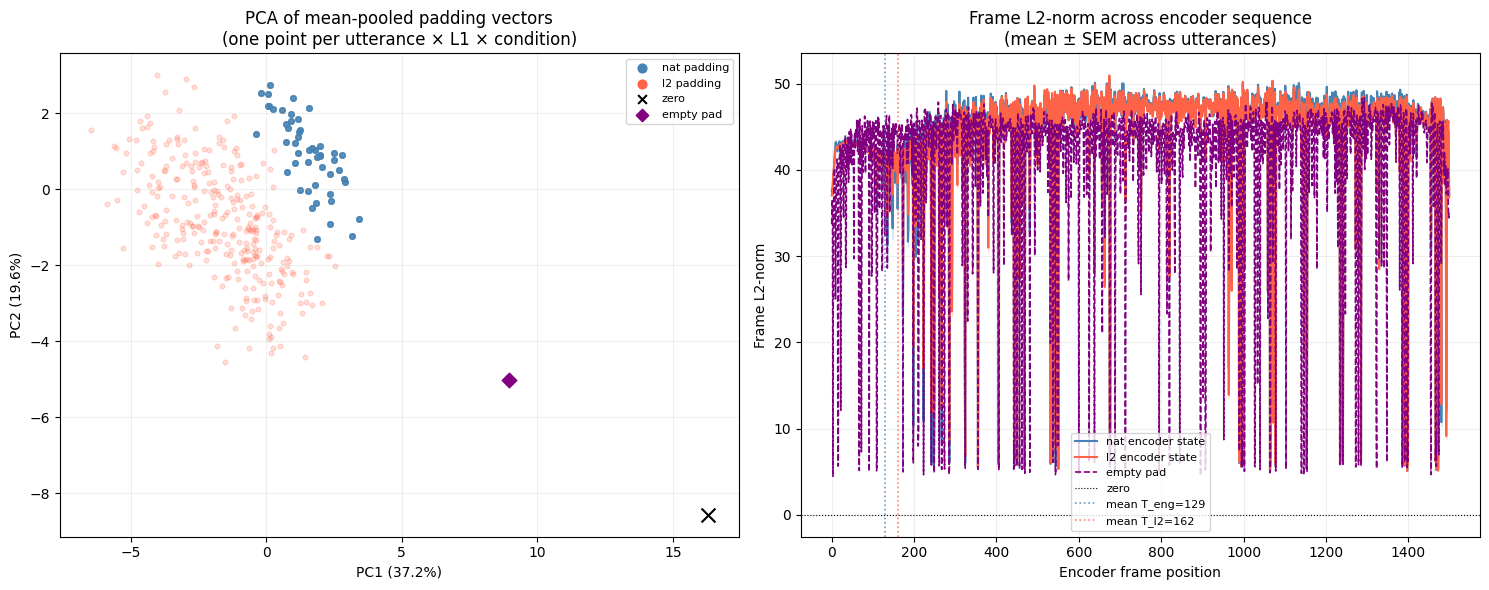

Saved padding_representations.png ✓


In [19]:
# Cell 8b — Padding representation geometry
# Two panels:
#   Left:  PCA of mean-pooled padding vectors — shows spatial layout of each condition
#   Right: Mean frame L2-norm vs encoder position — shows how signal evolves along the sequence
from sklearn.decomposition import PCA

# ── collect mean-pooled padding vectors ──────────────────────────────────────
pad_vecs, pad_meta = [], []
for pid in selected_pids:
    T_eng = states[pid]["English"]["speech_end"]
    z_nat = states[pid]["English"]["z"]
    nat_pad = z_nat[T_eng:]

    for l1 in ALL_L1S:
        T_l2  = states[pid][l1]["speech_end"]
        z_acc = states[pid][l1]["z"]
        l2_pad = z_acc[T_l2:]

        pad_vecs.extend([
            nat_pad.mean(0) if len(nat_pad) else np.zeros(768, dtype=np.float32),
            l2_pad.mean(0)  if len(l2_pad)  else np.zeros(768, dtype=np.float32),
        ])
        pad_meta.extend([("nat", l1), ("l2", l1)])

pad_vecs.append(np.zeros(768, dtype=np.float32))
pad_meta.append(("zero", "—"))
if z_empty_pad is not None:
    pad_vecs.append(z_empty_pad.mean(0))
    pad_meta.append(("empty", "—"))

vecs = np.stack(pad_vecs).astype(np.float32)
pca  = PCA(n_components=2, random_state=SEED)
pcs  = pca.fit_transform(vecs)

# ── frame-level L2-norm across full 1500-position sequence ───────────────────
nat_seqs  = np.stack([states[pid]["English"]["z"] for pid in selected_pids])          # [50,  1500, 768]
l2_seqs   = np.stack([states[pid][l1]["z"]
                      for pid in selected_pids for l1 in ALL_L1S])                    # [300, 1500, 768]
nat_norm  = np.linalg.norm(nat_seqs, axis=2)   # [50,  1500]
l2_norm   = np.linalg.norm(l2_seqs,  axis=2)   # [300, 1500]
mean_T_eng = int(np.mean([states[pid]["English"]["speech_end"] for pid in selected_pids]))
mean_T_l2  = int(np.mean([states[pid][l1]["speech_end"]
                           for pid in selected_pids for l1 in ALL_L1S]))

# ── plot ──────────────────────────────────────────────────────────────────────
CSTYLE = {
    "nat":   dict(c="steelblue", marker="o", alpha=0.30, s=16, label="nat padding"),
    "l2":    dict(c="tomato",    marker="o", alpha=0.20, s=12, label="l2 padding"),
    "zero":  dict(c="black",     marker="x", alpha=1.00, s=100, label="zero"),
    "empty": dict(c="purple",    marker="D", alpha=1.00, s=55,  label="empty pad"),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# — PCA —
ax = axes[0]
for i, (cond, l1) in enumerate(pad_meta):
    s = CSTYLE[cond]
    ax.scatter(pcs[i, 0], pcs[i, 1], c=s["c"], marker=s["marker"],
               alpha=s["alpha"], s=s["s"])
for cond, s in CSTYLE.items():
    if any(m[0] == cond for m in pad_meta):
        ax.scatter([], [], c=s["c"], marker=s["marker"], s=40, label=s["label"])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA of mean-pooled padding vectors\n(one point per utterance × L1 × condition)")
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# — Frame norm —
ax = axes[1]
xs = np.arange(1500)
for arr, color, label in [(nat_norm, "steelblue", "nat"), (l2_norm, "tomato", "l2")]:
    mn = arr.mean(0); se = arr.std(0) / np.sqrt(len(arr))
    ax.plot(xs, mn, color=color, lw=1.5, label=f"{label} encoder state")
    ax.fill_between(xs, mn - se, mn + se, color=color, alpha=0.18)
if z_empty_pad is not None:
    ax.plot(xs, np.linalg.norm(z_empty_pad, axis=1),
            color="purple", lw=1.2, ls="--", label="empty pad")
ax.axhline(0, color="black", lw=0.8, ls=":", label="zero")
ax.axvline(mean_T_eng, color="steelblue", lw=1.2, ls=":", alpha=0.8,
           label=f"mean T_eng={mean_T_eng}")
ax.axvline(mean_T_l2,  color="tomato",   lw=1.2, ls=":", alpha=0.8,
           label=f"mean T_l2={mean_T_l2}")
ax.set_xlabel("Encoder frame position")
ax.set_ylabel("Frame L2-norm")
ax.set_title("Frame L2-norm across encoder sequence\n(mean ± SEM across utterances)")
ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / "padding_representations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved padding_representations.png ✓")

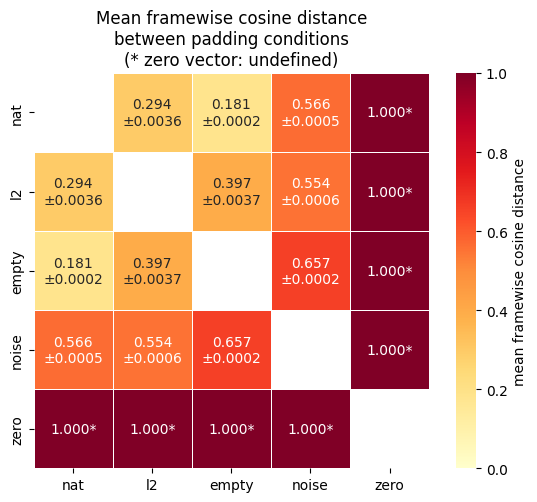

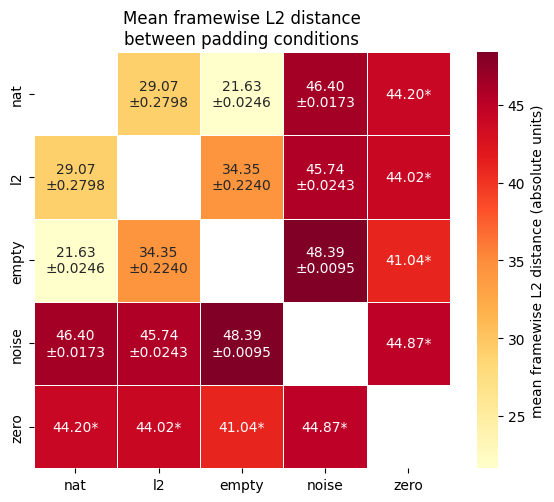

/tmp/ipykernel_2673194/1497896168.py:138: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[l1] for l1 in ALL_L1S], labels=ALL_L1S, patch_artist=True,
/tmp/ipykernel_2673194/1497896168.py:138: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[l1] for l1 in ALL_L1S], labels=ALL_L1S, patch_artist=True,


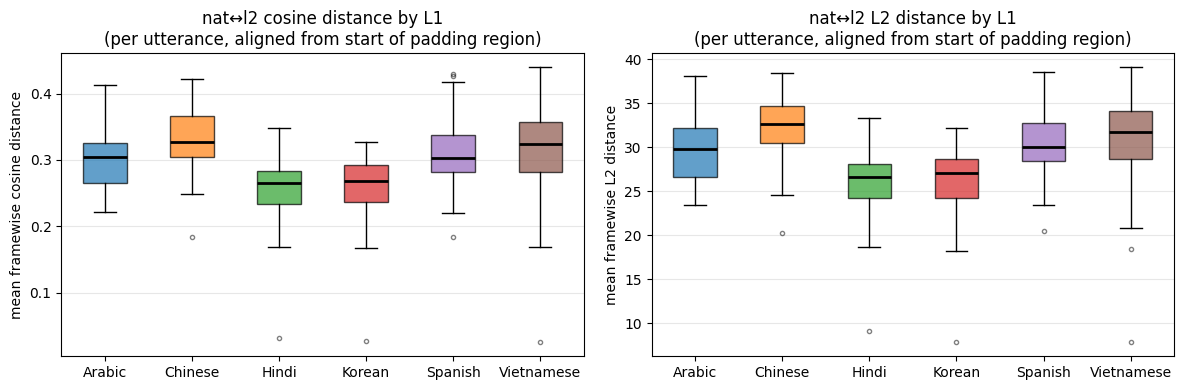

Saved padding_cosine_heatmap.png, padding_l2_heatmap.png, padding_nat_l2_boxplot.png ✓


In [23]:
# Cell 8c — Framewise distance between padding conditions (cosine + L2)
# Three separate figures:
#   1. Mean framewise cosine distance heatmap (direction similarity, scale-invariant)
#   2. Mean framewise L2 distance heatmap (magnitude of deviation, scale-sensitive)
#   3. nat↔l2 distance boxplot by L1 (both metrics)
#
# Why framewise over mean-pooled? Mean-pooling is first-order only. nat↔noise has
# near-zero mean-pooled cosine distance (noise matched in mean/std to nat) yet
# nat+noise WER is 0.77. Framewise metrics reveal structural disruption that pooling hides.

def mean_framewise_cosine_dist(seq_a: np.ndarray, seq_b: np.ndarray) -> float:
    """Mean cosine distance at each aligned frame. Clips to min(len_a, len_b)."""
    n = min(len(seq_a), len(seq_b))
    if n == 0:
        return np.nan
    a = seq_a[:n].astype(np.float32)
    b = seq_b[:n].astype(np.float32)
    norm_a = np.linalg.norm(a, axis=1, keepdims=True) + 1e-10
    norm_b = np.linalg.norm(b, axis=1, keepdims=True) + 1e-10
    return float((1.0 - ((a / norm_a) * (b / norm_b)).sum(axis=1)).mean())

def mean_framewise_l2_dist(seq_a: np.ndarray, seq_b: np.ndarray) -> float:
    """Mean L2 distance at each aligned frame. Clips to min(len_a, len_b)."""
    n = min(len(seq_a), len(seq_b))
    if n == 0:
        return np.nan
    return float(np.linalg.norm(
        seq_a[:n].astype(np.float32) - seq_b[:n].astype(np.float32), axis=1
    ).mean())

# ── build per-(pid, l1) padding sequences ────────────────────────────────────
records = []
for pid in selected_pids:
    T_eng = states[pid]["English"]["speech_end"]
    z_nat = states[pid]["English"]["z"]
    nat_pad = z_nat[T_eng:]

    for l1 in ALL_L1S:
        T_l2  = states[pid][l1]["speech_end"]
        z_acc = states[pid][l1]["z"]
        l2_pad = z_acc[T_l2:]

        _mean = nat_pad.mean(0, keepdims=True) if len(nat_pad) else np.zeros((1, 768), dtype=np.float32)
        _std  = (nat_pad.std(0, keepdims=True) + 1e-6) if len(nat_pad) else np.ones((1, 768), dtype=np.float32)
        noise_pad = np.random.RandomState(SEED).randn(len(nat_pad), 768).astype(np.float32) * _std + _mean

        records.append({"pid": pid, "l1": l1, "nat": nat_pad, "l2": l2_pad,
                        "noise": noise_pad, "T_eng": T_eng})

def get_seq(rec: dict, cond: str) -> np.ndarray | None:
    T_eng = rec["T_eng"]
    if cond == "nat":   return rec["nat"]
    if cond == "l2":    return rec["l2"]
    if cond == "noise": return rec["noise"]
    if cond == "empty": return z_empty_pad[T_eng:] if z_empty_pad is not None else None
    if cond == "zero":  return np.zeros((1500 - T_eng, 768), dtype=np.float32)

cond_names = [c for c in ["nat", "l2", "empty", "noise", "zero"]
              if not (c == "empty" and z_empty_pad is None)]
ZERO_CONDS = {"zero"}

# ── compute both pairwise distance matrices in one pass ──────────────────────
nc = len(cond_names)
cos_mean = np.zeros((nc, nc)); cos_sem = np.zeros((nc, nc))
l2_mean  = np.zeros((nc, nc)); l2_sem  = np.zeros((nc, nc))

for i, ca in enumerate(cond_names):
    for j, cb in enumerate(cond_names):
        if i == j:
            continue
        cos_d, l2_d = [], []
        for rec in records:
            sa, sb = get_seq(rec, ca), get_seq(rec, cb)
            if sa is None or sb is None:
                continue
            dc = mean_framewise_cosine_dist(sa, sb)
            dl = mean_framewise_l2_dist(sa, sb)
            if not np.isnan(dc): cos_d.append(dc)
            if not np.isnan(dl): l2_d.append(dl)
        for dists, m, s in [(cos_d, cos_mean, cos_sem), (l2_d, l2_mean, l2_sem)]:
            if dists:
                a = np.array(dists)
                m[i, j] = a.mean()
                s[i, j] = a.std(ddof=1) / np.sqrt(len(a))

# ── nat↔l2 per-utterance distances for boxplot ───────────────────────────────
nat_l2_cos = {l1: [] for l1 in ALL_L1S}
nat_l2_l2  = {l1: [] for l1 in ALL_L1S}
for rec in records:
    dc = mean_framewise_cosine_dist(rec["nat"], rec["l2"])
    dl = mean_framewise_l2_dist(rec["nat"], rec["l2"])
    if not np.isnan(dc): nat_l2_cos[rec["l1"]].append(dc)
    if not np.isnan(dl): nat_l2_l2[rec["l1"]].append(dl)

# ── helper: annotation matrix ─────────────────────────────────────────────────
def _annot(m, s, val_fmt=".3f"):
    A = np.empty((nc, nc), dtype=object)
    for i in range(nc):
        for j in range(nc):
            if i == j:
                A[i, j] = "—"
            elif cond_names[i] in ZERO_CONDS or cond_names[j] in ZERO_CONDS:
                A[i, j] = f"{m[i,j]:{val_fmt}}*"
            else:
                A[i, j] = f"{m[i,j]:{val_fmt}}\n±{s[i,j]:.4f}"
    return A

# ── Figure 1: cosine distance heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
pm = cos_mean.copy(); np.fill_diagonal(pm, np.nan)
sns.heatmap(pm, annot=_annot(cos_mean, cos_sem), fmt="s",
            xticklabels=cond_names, yticklabels=cond_names,
            cmap="YlOrRd", vmin=0, vmax=1, ax=ax, linewidths=0.5, square=True,
            cbar_kws={"label": "mean framewise cosine distance"})
ax.set_title("Mean framewise cosine distance\nbetween padding conditions\n(* zero vector: undefined)")
plt.tight_layout()
plt.savefig(OUT_DIR / "padding_cosine_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: L2 distance heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
pm = l2_mean.copy(); np.fill_diagonal(pm, np.nan)
sns.heatmap(pm, annot=_annot(l2_mean, l2_sem, val_fmt=".2f"), fmt="s",
            xticklabels=cond_names, yticklabels=cond_names,
            cmap="YlOrRd", ax=ax, linewidths=0.5, square=True,
            cbar_kws={"label": "mean framewise L2 distance (absolute units)"})
ax.set_title("Mean framewise L2 distance\nbetween padding conditions")
plt.tight_layout()
plt.savefig(OUT_DIR / "padding_l2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: nat↔l2 distance boxplot by L1 (cosine + L2) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, ylabel, title in [
    (axes[0], nat_l2_cos, "mean framewise cosine distance", "nat↔l2 cosine distance by L1"),
    (axes[1], nat_l2_l2,  "mean framewise L2 distance",    "nat↔l2 L2 distance by L1"),
]:
    bp = ax.boxplot([data[l1] for l1 in ALL_L1S], labels=ALL_L1S, patch_artist=True,
                    medianprops=dict(color="black", lw=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))
    for patch, color in zip(bp["boxes"], sns.color_palette("tab10", len(ALL_L1S))):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title + "\n(per utterance, aligned from start of padding region)")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "padding_nat_l2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved padding_cosine_heatmap.png, padding_l2_heatmap.png, padding_nat_l2_boxplot.png ✓")

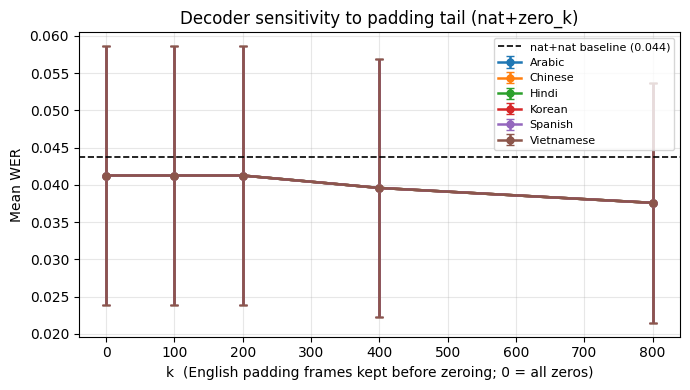

Saved wer_zero_k_curve.png ✓


In [11]:
# Cell 10 — WER vs k curve (nat+zero_k sensitivity threshold)
zero_df = df[df["condition"].str.startswith("nat+zero_")].dropna(subset=["wer"]).copy()
zero_df["k"] = zero_df["condition"].str.replace("nat+zero_", "").astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
for l1, color in zip(ALL_L1S, COLORS):
    sub   = zero_df[zero_df["L1"] == l1]
    stats = (sub.groupby("k")["wer"]
             .agg(mean="mean", sem=lambda x: x.std(ddof=1) / len(x)**0.5)
             .reset_index())
    ax.errorbar(stats["k"], stats["mean"], yerr=stats["sem"],
                fmt="o-", label=l1, color=color, lw=1.8, ms=5, capsize=3)

nat_mean = df[df["condition"] == "nat+nat"]["wer"].dropna().mean()
ax.axhline(nat_mean, color="black", ls="--", lw=1.2,
           label=f"nat+nat baseline ({nat_mean:.3f})")
ax.set_xlabel("k  (English padding frames kept before zeroing; 0 = all zeros)")
ax.set_ylabel("Mean WER")
ax.set_title("Decoder sensitivity to padding tail (nat+zero_k)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "wer_zero_k_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved wer_zero_k_curve.png ✓")

In [31]:
# Cell 11 — Attention extraction: on-manifold vs off-manifold conditions
# Tests the hypothesis: off-manifold padding (noise, interp) causes generation failures
# (truncation, hallucination, repetition); on-manifold (nat, l2) does not.
# sdpa (flash) attention doesn't support output_attentions — load a separate
# eager-attention model just for this cell; main whisper_model is unchanged.
from transformers import WhisperForConditionalGeneration

whisper_eager = WhisperForConditionalGeneration.from_pretrained(
    whisper_model.config._name_or_path,
    attn_implementation="eager",
    local_files_only=True,
).to(device).eval()
print("Eager-attention Whisper loaded ✓")

# on-manifold: nat+nat (gold), nat+l2_same (swap — known to be equivalent)
# off-manifold: nat+interp (mild, WER +65%), nat+noise (severe, WER +1600%)
ATTN_CONDS    = ["nat+nat", "nat+l2_same", "nat+interp", "nat+noise"]
ATTN_N_PER_L1 = 20   # 2 prompts × 6 L1s = 12 pairs
attn_subset   = [(pid, l1)
                 for pid in selected_pids[:ATTN_N_PER_L1]
                 for l1 in ALL_L1S]
print(f"Attention subset: {len(attn_subset)} (pid, L1) pairs × {len(ATTN_CONDS)} conditions")

def decode_with_attentions(z: np.ndarray) -> tuple[str, np.ndarray]:
    """
    Returns (transcription, attn_map [T_decode, 1500]).
    Cross-attention from the final decoder layer, averaged over heads.
    Uses whisper_eager (attn_implementation=\'eager\') so attention weights are available.
    """
    enc = BaseModelOutput(
        last_hidden_state=torch.from_numpy(z).unsqueeze(0).to(device)
    )
    with torch.no_grad():
        out = whisper_eager.generate(
            encoder_outputs=enc,
            language="en", task="transcribe", temperature=0.0,
            output_attentions=True,
            return_dict_in_generate=True,
        )
    # cross_attentions: tuple[num_steps] of tuple[num_layers] of [batch,heads,query_len,1500]
    # take [-1] on query dim: robust to forced-prefix steps where query_len > 1
    attn_steps = [
        step[-1][0].mean(0)[-1].float().cpu().numpy()  # last query pos -> [1500]
        for step in out.cross_attentions
    ]
    return (processor.decode(out.sequences[0], skip_special_tokens=True),
            np.stack(attn_steps))   # [T_decode, 1500]

attn_results: dict[tuple, dict] = {}
for pid, l1 in tqdm(attn_subset, desc="attention decodes"):
    conds = build_conditions(pid, l1)
    for cond in ATTN_CONDS:
        text, attn_map = decode_with_attentions(conds[cond])
        attn_results[(pid, l1, cond)] = {"text": text, "attn": attn_map}

print(f"Extracted {len(attn_results)} attention maps")
ex = list(attn_results.values())[0]
print("  attn shape:", ex["attn"].shape, "(T_decode × 1500)")
print("  example:   ", ex["text"][:80])

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Eager-attention Whisper loaded ✓
Attention subset: 120 (pid, L1) pairs × 4 conditions


attention decodes: 100%|██████████| 120/120 [01:16<00:00,  1.57it/s]

Extracted 480 attention maps
  attn shape: (10, 1500) (T_decode × 1500)
  example:     I was the only one who remained sitting.


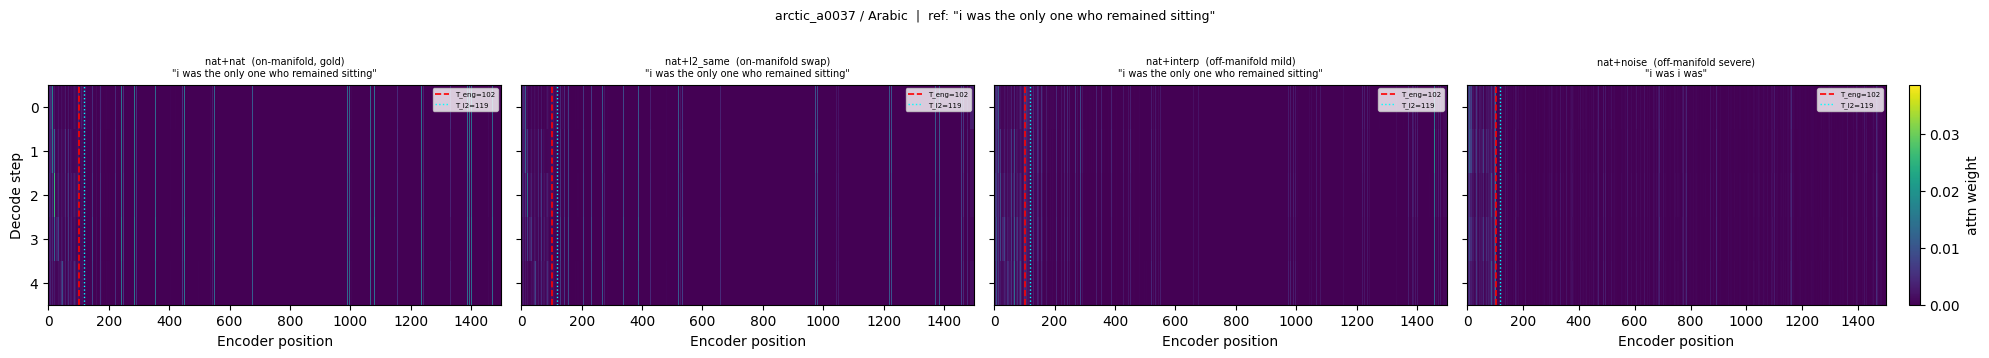

Saved attn_heatmap_arctic_a0037_Arabic.png


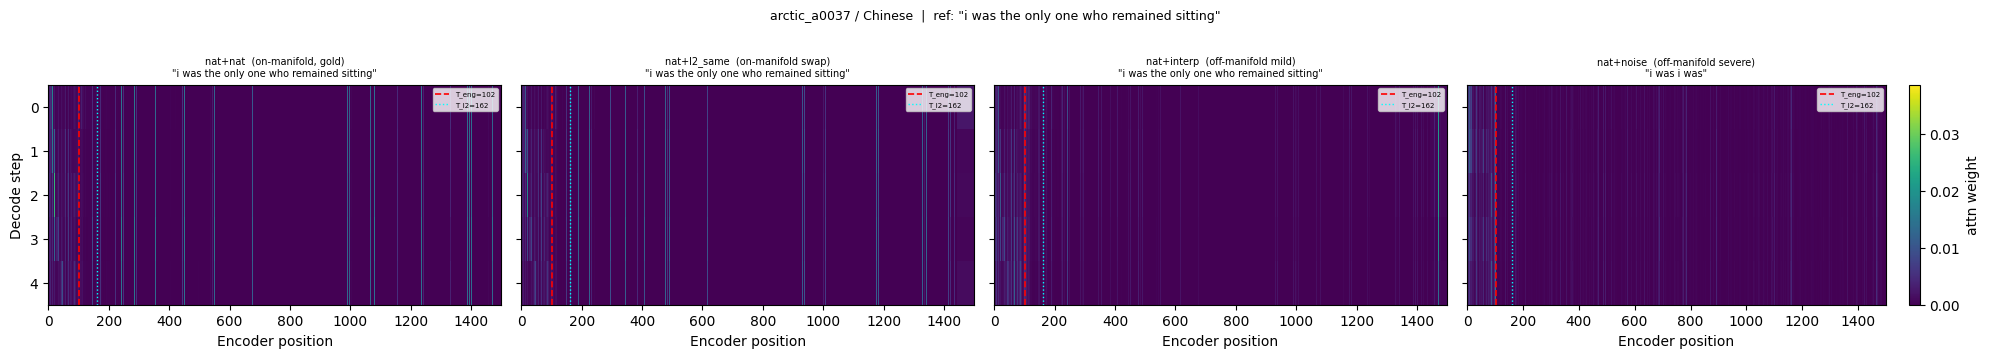

Saved attn_heatmap_arctic_a0037_Chinese.png


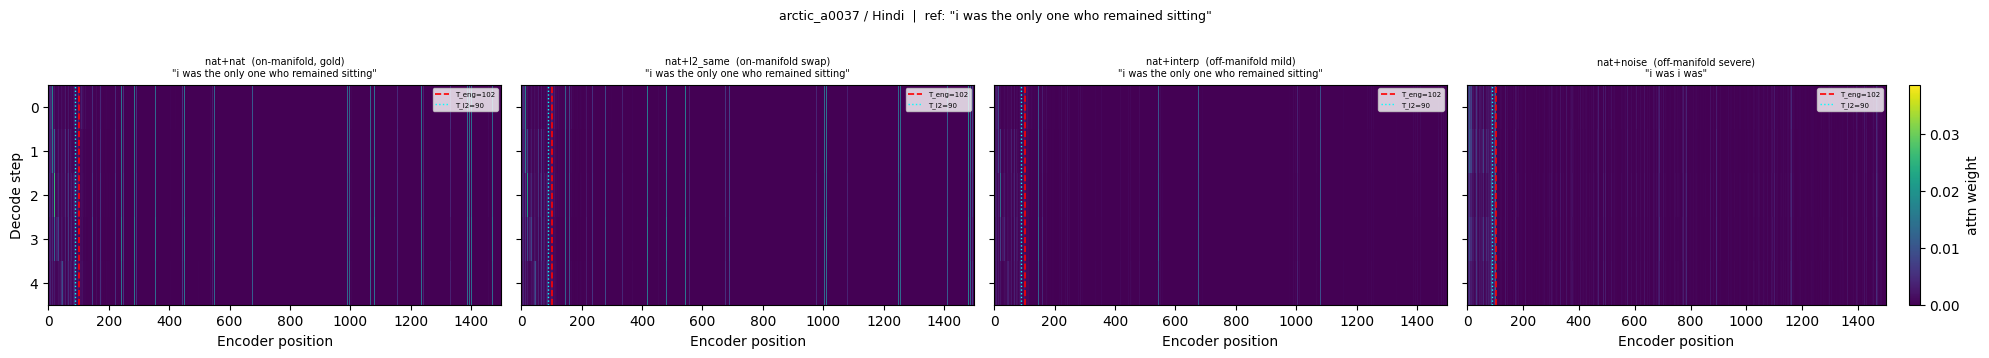

Saved attn_heatmap_arctic_a0037_Hindi.png


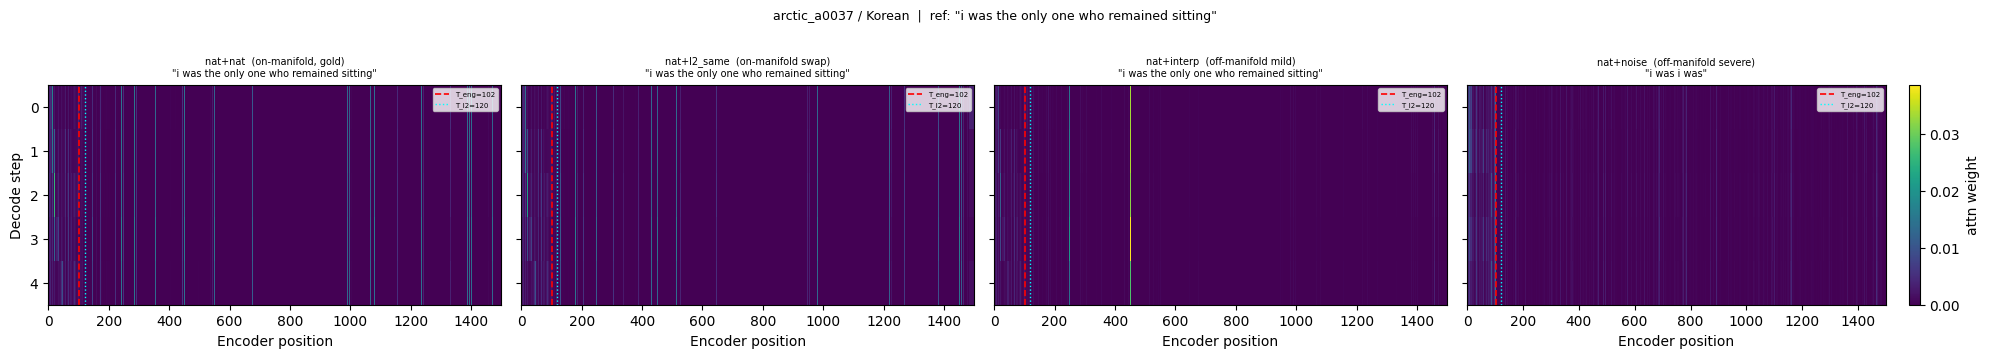

Saved attn_heatmap_arctic_a0037_Korean.png


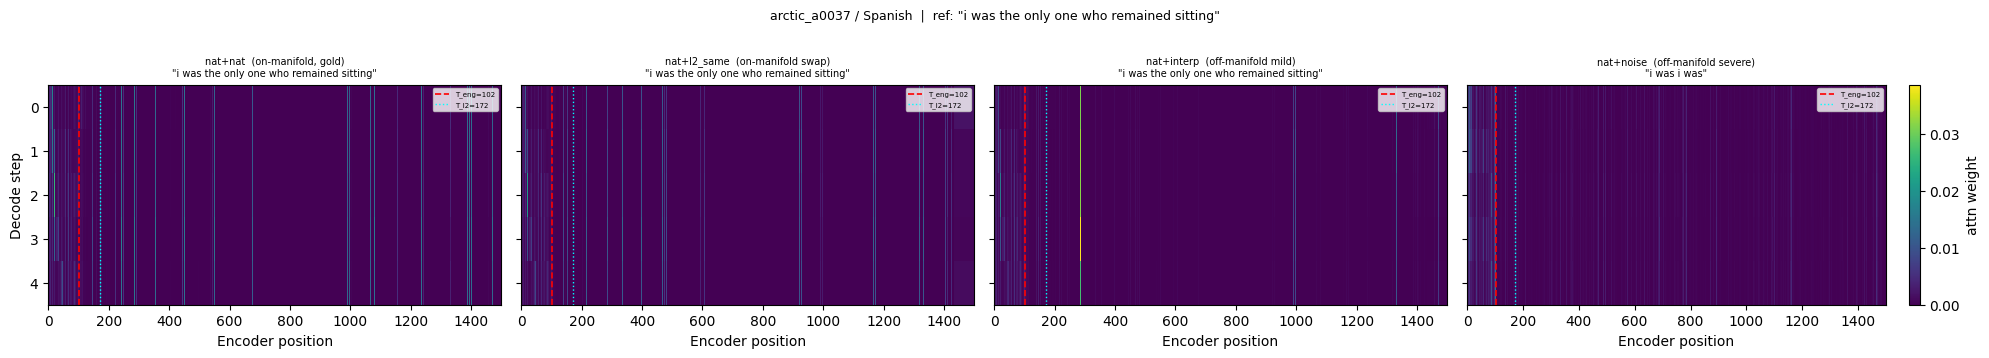

Saved attn_heatmap_arctic_a0037_Spanish.png


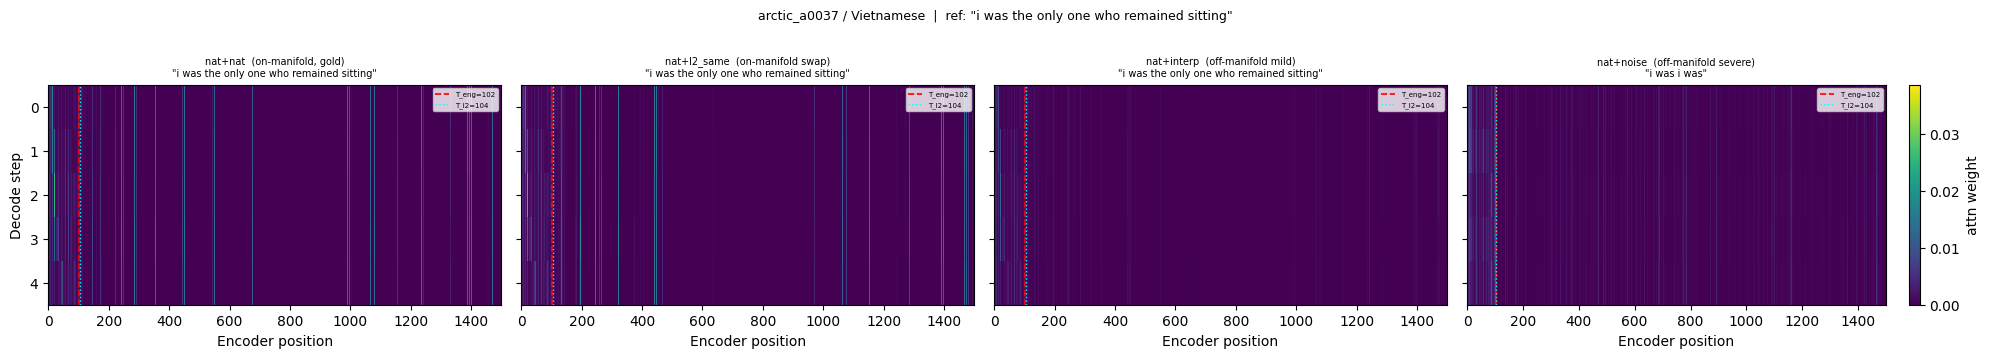

Saved attn_heatmap_arctic_a0037_Vietnamese.png


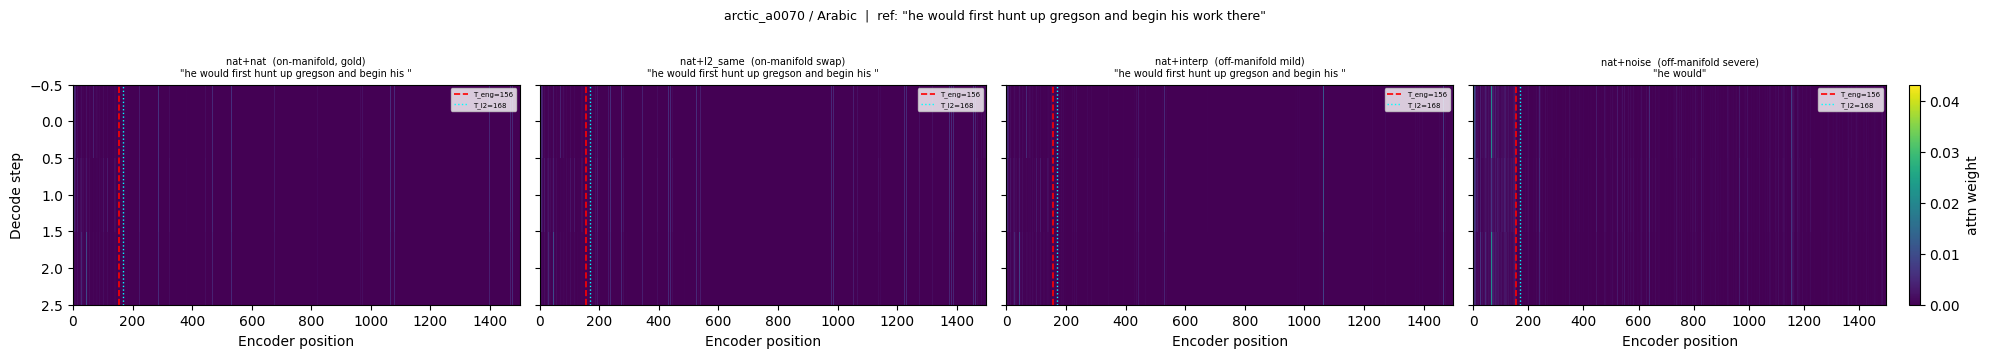

Saved attn_heatmap_arctic_a0070_Arabic.png


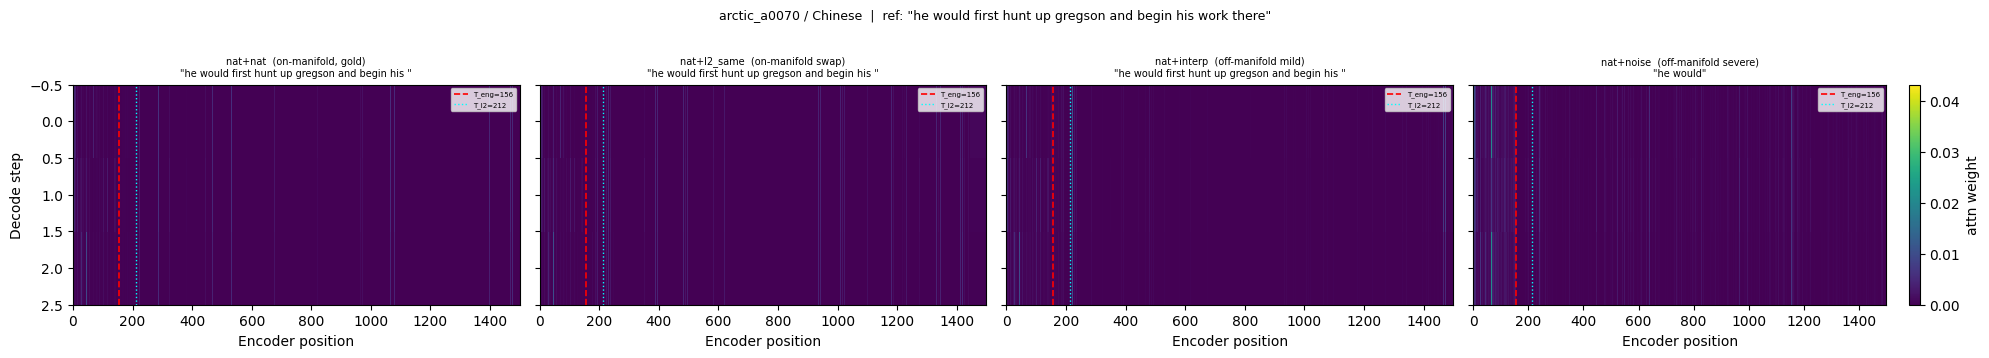

Saved attn_heatmap_arctic_a0070_Chinese.png


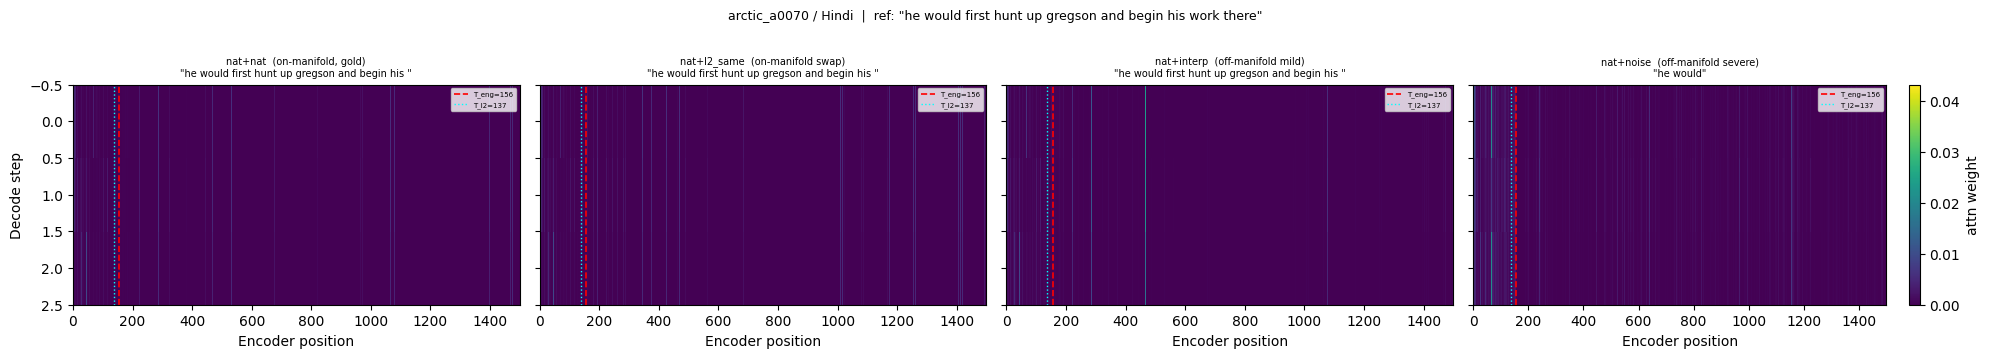

Saved attn_heatmap_arctic_a0070_Hindi.png


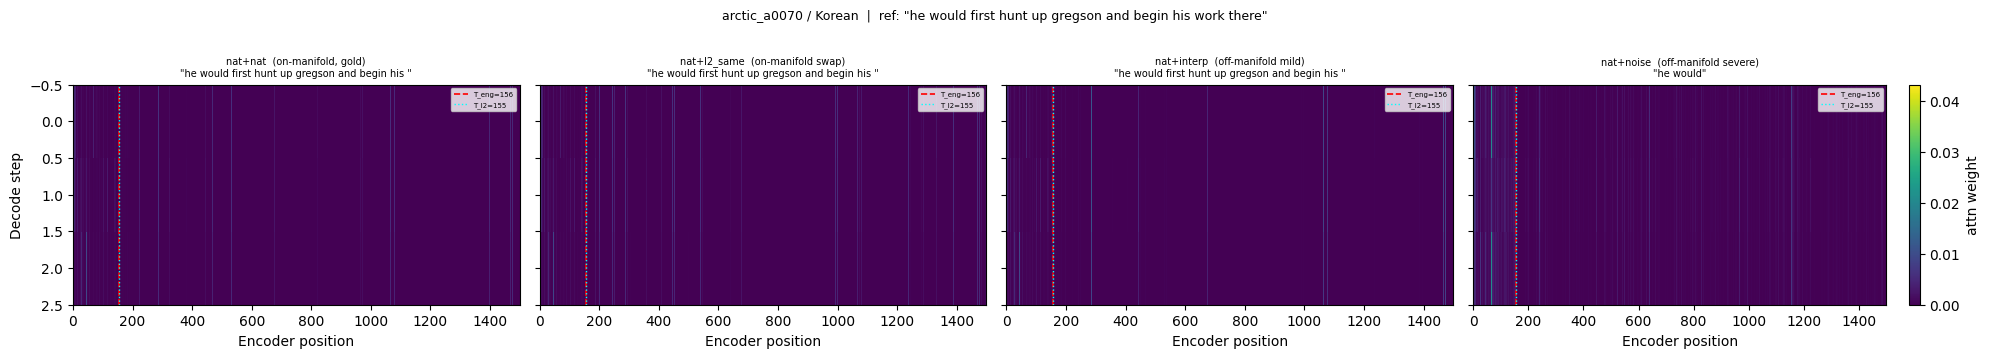

Saved attn_heatmap_arctic_a0070_Korean.png


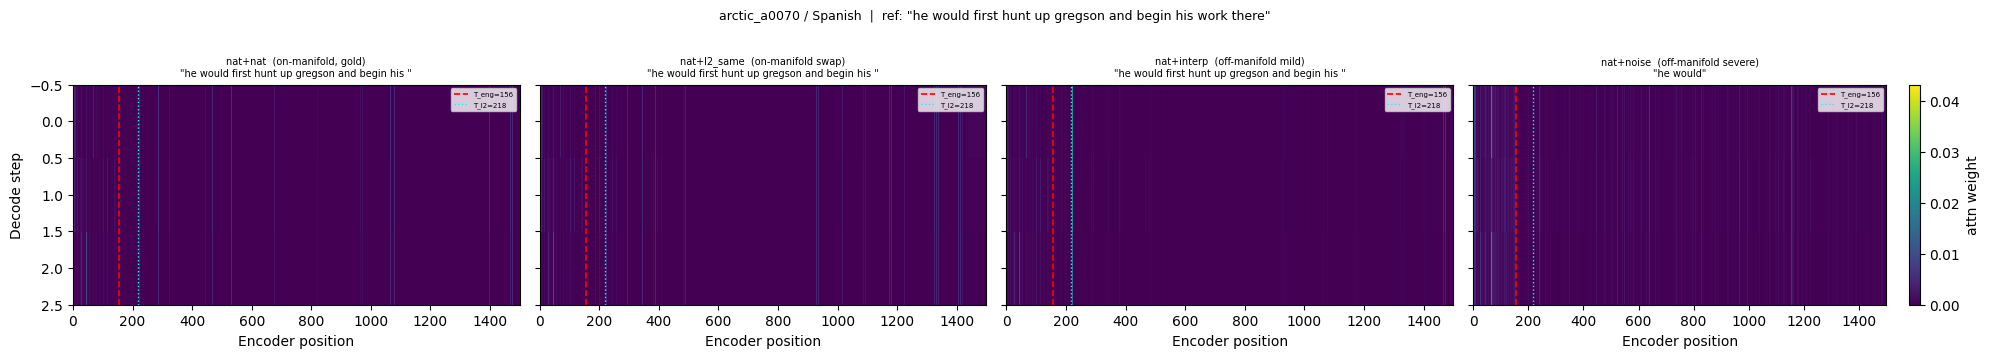

Saved attn_heatmap_arctic_a0070_Spanish.png


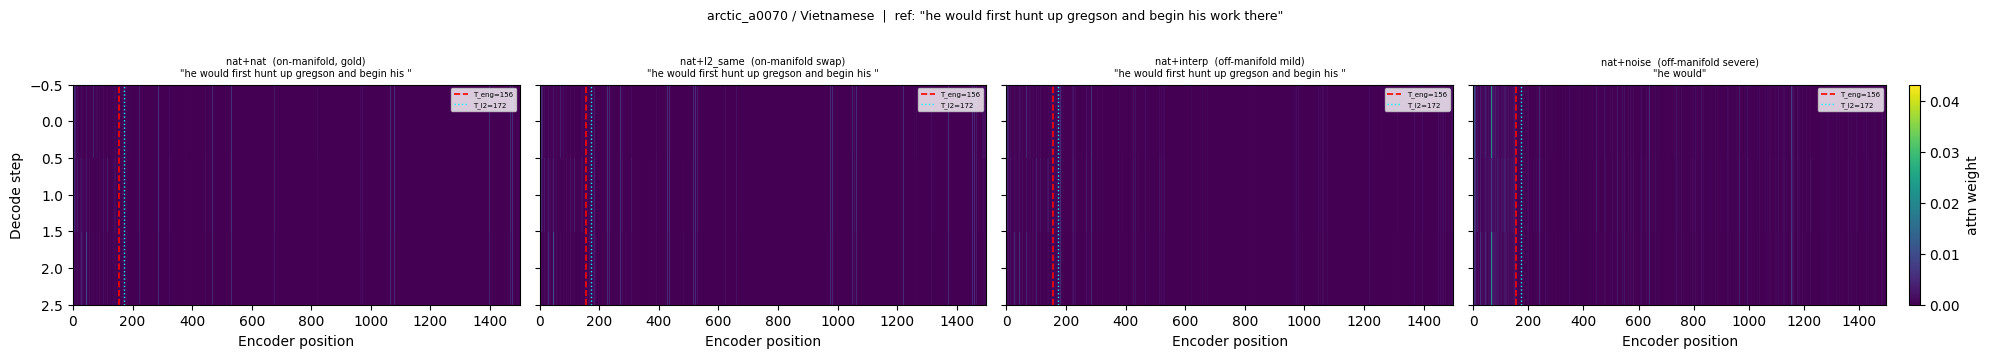

Saved attn_heatmap_arctic_a0070_Vietnamese.png


In [ ]:
# Cell 12 — Attention heatmaps: 4-panel per utterance (one per condition)
# on-manifold (nat+nat, nat+l2_same) should look similar;
# off-manifold (nat+interp, nat+noise) may show diffuse, shifted, or truncated attention.
COND_TITLES = {
    "nat+nat":      "nat+nat  (on-manifold, gold)",
    "nat+l2_same":  "nat+l2_same  (on-manifold swap)",
    "nat+interp":   "nat+interp  (off-manifold mild)",
    "nat+noise":    "nat+noise  (off-manifold severe)",
}

for pid, l1 in attn_subset:
    T_eng = states[pid]["English"]["speech_end"]
    T_l2  = states[pid][l1]["speech_end"]
    ref   = _norm(pid_to_text.get(pid, ""))

    fig, axes = plt.subplots(1, 4, figsize=(20, 3.5), sharey=True)
    for ax, cond in zip(axes, ATTN_CONDS):
        res      = attn_results[(pid, l1, cond)]
        attn_map = res["attn"]
        hyp      = _norm(res["text"])
        im = ax.imshow(attn_map, aspect="auto", origin="upper",
                       cmap="viridis", vmin=0, interpolation="nearest")
        ax.axvline(T_eng, color="red",  lw=1.2, ls="--", label=f"T_eng={T_eng}")
        ax.axvline(T_l2,  color="cyan", lw=1.0, ls=":",  label=f"T_l2={T_l2}")
        ax.set_title(f"{COND_TITLES[cond]}\n\"{hyp[:45]}\"", fontsize=7)
        ax.set_xlabel("Encoder position")
        ax.legend(fontsize=5, loc="upper right")
    axes[0].set_ylabel("Decode step")
    fig.suptitle(f"{pid} / {l1}  |  ref: \"{ref[:70]}\"", fontsize=9, y=1.01)
    plt.colorbar(im, ax=axes[-1], fraction=0.025, label="attn weight")
    plt.tight_layout()
    save_path = OUT_DIR / f"attn_heatmap_{pid}_{l1}.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path.name}")

/vol/gpudata/tsv22-fyp/accent-robust-asr/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


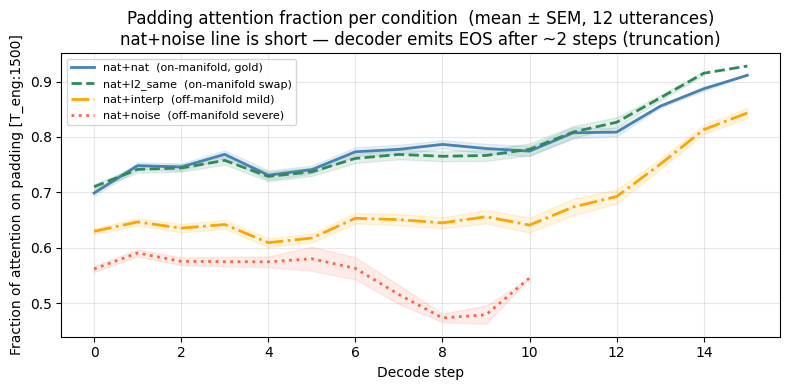

Saved attn_padding_fraction.png ✓


In [32]:
# Cell 13 — Padding attention fraction: on-manifold vs off-manifold
# Key question: does off-manifold padding (noise, interp) pull decoder attention into the
# padding region [T_eng:1500], or does it cause diffuse/collapsed attention elsewhere?
# NOTE: nat+noise generates very few decode steps (extreme truncation — decoder emits EOS
# almost immediately). Sequences are NaN-padded to max_len so shorter lines appear as stubs
# rather than clipping all conditions to the truncated length.

def _nan_agg(fracs_list):
    """Stack variable-length arrays with NaN padding, return (mean, sem, xs)."""
    max_len = max(len(f) for f in fracs_list)
    mat = np.full((len(fracs_list), max_len), np.nan)
    for k, f in enumerate(fracs_list):
        mat[k, :len(f)] = f
    with np.errstate(all="ignore"):
        mean    = np.nanmean(mat, axis=0)
        n_valid = (~np.isnan(mat)).sum(axis=0)
        sem     = np.nanstd(mat, ddof=1, axis=0) / np.sqrt(np.maximum(n_valid, 1))
    return mean, sem, np.arange(max_len)

fig, ax = plt.subplots(figsize=(8, 4))
for cond in ATTN_CONDS:
    fracs = []
    for pid, l1 in attn_subset:
        T_eng    = states[pid]["English"]["speech_end"]
        attn_map = attn_results[(pid, l1, cond)]["attn"]  # [T_decode, 1500]
        total    = attn_map.sum(axis=1)
        frac     = np.where(total > 1e-8,
                            attn_map[:, T_eng:].sum(axis=1) / total, 0.0)
        fracs.append(frac)

    mean, sem, xs = _nan_agg(fracs)
    ax.plot(xs, mean, lw=2, ls=COND_LS[cond], color=COND_COLORS[cond], label=COND_TITLES[cond])
    ax.fill_between(xs, mean - sem, mean + sem, color=COND_COLORS[cond], alpha=0.12)

ax.set_xlabel("Decode step")
ax.set_ylabel("Fraction of attention on padding [T_eng:1500]")
ax.set_title("Padding attention fraction per condition  (mean ± SEM, 12 utterances)\n"
             "nat+noise line is short — decoder emits EOS after ~2 steps (truncation)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "attn_padding_fraction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved attn_padding_fraction.png ✓")

=== Generation pathology by condition ===
               n  mean_WER  mean_len_ratio pct_truncated pct_repeating
condition                                                             
nat+nat      120     0.047            1.00            0%            0%
nat+l2_same  120     0.044            1.00            0%            0%
nat+interp   120     0.059            0.98            2%            0%
nat+noise    120     0.751            0.43           70%            0%


/tmp/ipykernel_2673194/3773709345.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ATTN_CONDS, patch_artist=True,


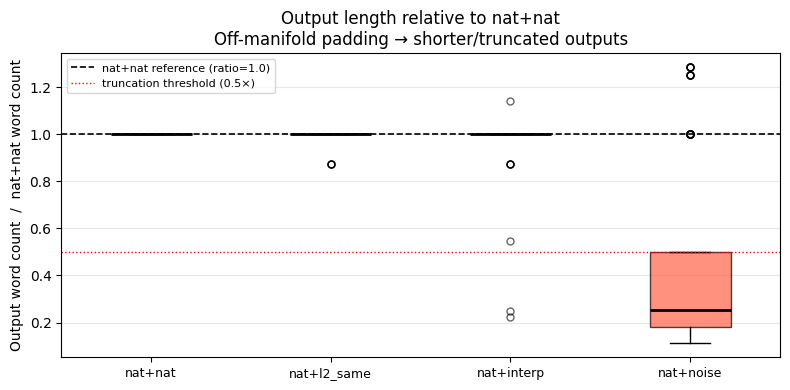

/vol/gpudata/tsv22-fyp/accent-robust-asr/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


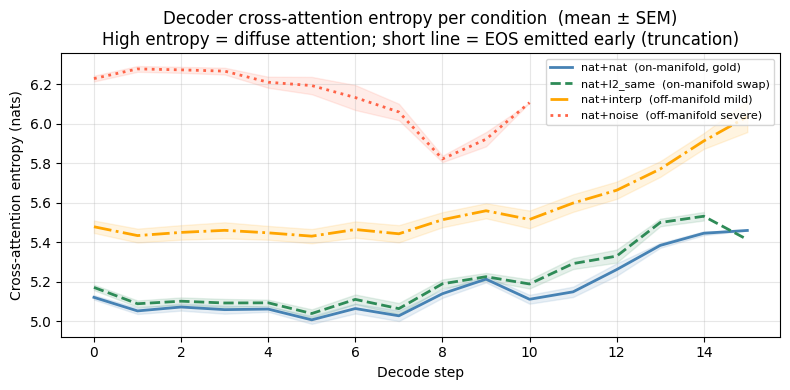

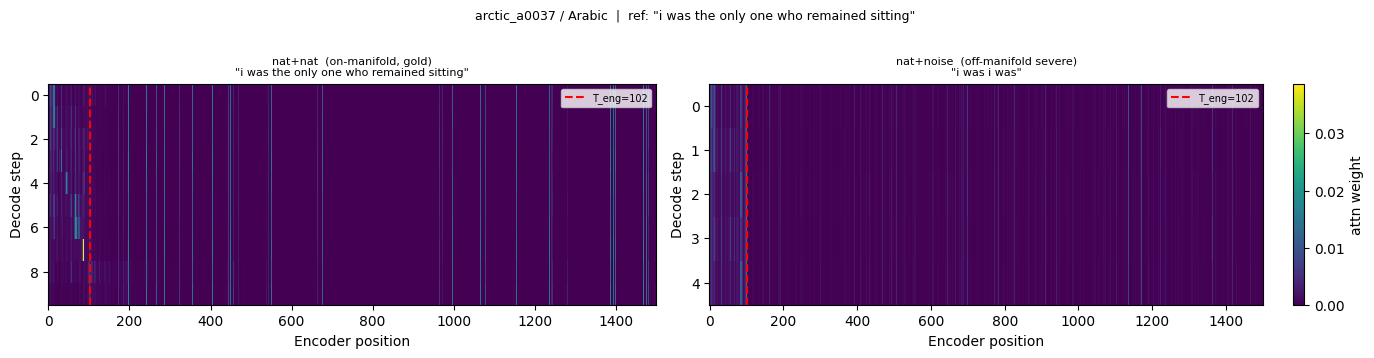

Saved pathology_attn_arctic_a0037_Arabic.png


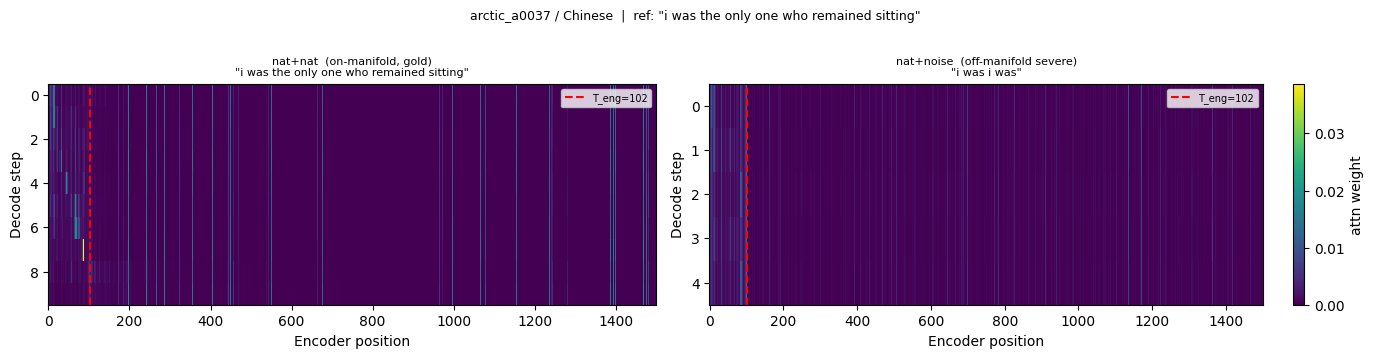

Saved pathology_attn_arctic_a0037_Chinese.png


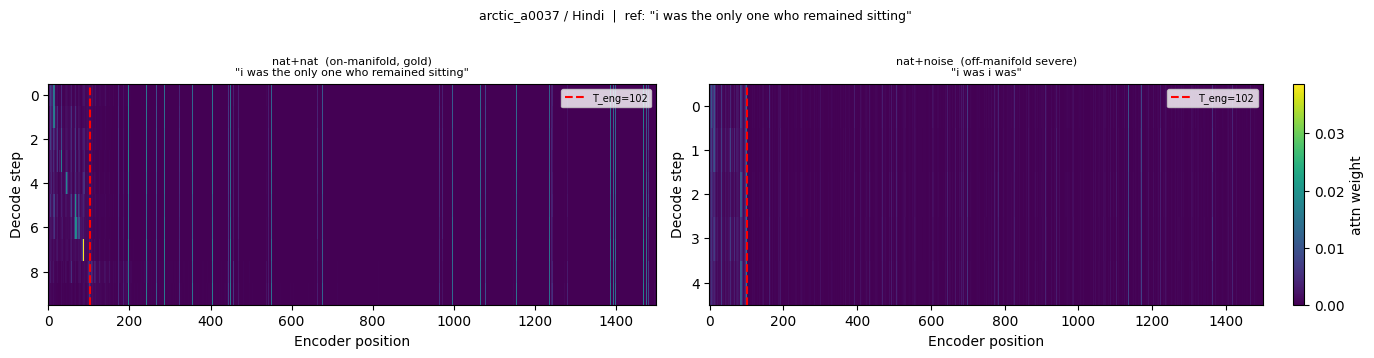

Saved pathology_attn_arctic_a0037_Hindi.png


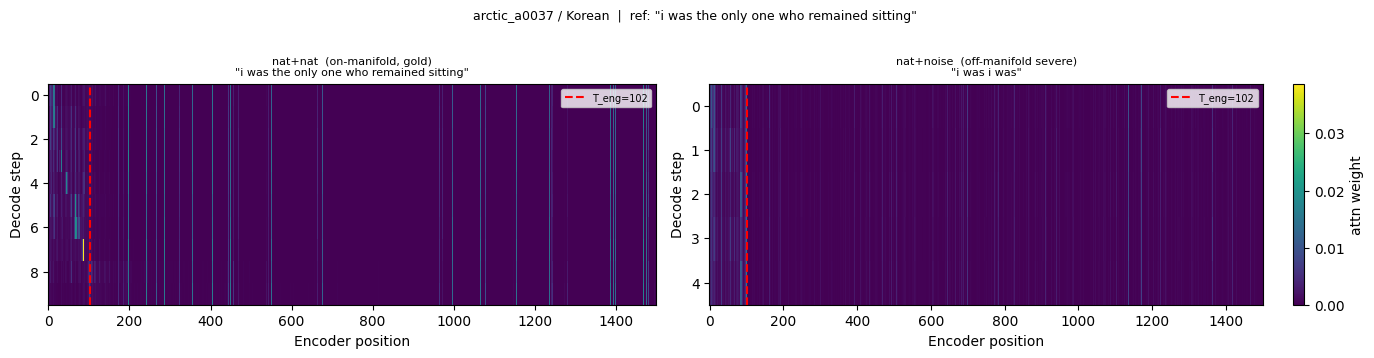

Saved pathology_attn_arctic_a0037_Korean.png
Saved pathology_length_ratio.png, pathology_attn_entropy.png ✓


In [33]:
# Cell 14 — Generation pathology: truncation, repetition, hallucination
# Mechanistic evidence for the off-manifold padding hypothesis.
# For each (pid, l1, cond), compare output length against nat+nat and detect failure modes:
#   - Truncation:   output < 50% of nat+nat word count
#   - Repetition:   any 4-gram appears >= 3 times
# Expected: nat+nat and nat+l2_same clean; nat+interp partial degradation; nat+noise severe.

import pandas as pd

def detect_repetition(text: str, min_repeat: int = 3, ngram: int = 4) -> bool:
    words = text.lower().split()
    if len(words) < ngram:
        return False
    grams = [" ".join(words[i:i+ngram]) for i in range(len(words)-ngram+1)]
    return any(grams.count(g) >= min_repeat for g in set(grams))

# ── per-(pid, l1, cond) generation stats ─────────────────────────────────────
records_14 = []
for pid, l1 in attn_subset:
    ref = _norm(pid_to_text.get(pid, ""))
    nat_hyp = _norm(attn_results[(pid, l1, "nat+nat")]["text"])
    nat_len = max(len(nat_hyp.split()), 1)

    for cond in ATTN_CONDS:
        hyp     = _norm(attn_results[(pid, l1, cond)]["text"])
        hyp_len = len(hyp.split())
        records_14.append({
            "pid": pid, "l1": l1, "condition": cond,
            "hyp": hyp, "ref": ref,
            "hyp_len":   hyp_len,
            "nat_len":   nat_len,
            "len_ratio": hyp_len / nat_len,
            "truncated": hyp_len < 0.5 * nat_len,
            "repeating": detect_repetition(hyp),
            "wer":       utt_wer(ref, hyp),
        })

df_14 = pd.DataFrame(records_14)

# ── summary table ─────────────────────────────────────────────────────────────
summary_14 = (
    df_14.groupby("condition")
    .agg(
        n=("hyp_len", "count"),
        mean_WER=("wer", "mean"),
        mean_len_ratio=("len_ratio", "mean"),
        pct_truncated=("truncated", lambda x: f"{x.mean()*100:.0f}%"),
        pct_repeating=("repeating", lambda x: f"{x.mean()*100:.0f}%"),
    )
    .reindex(ATTN_CONDS)
    .round({"mean_WER": 3, "mean_len_ratio": 2})
)
print("=== Generation pathology by condition ===")
print(summary_14.to_string())

# ── Figure 1: output length ratio per condition ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
data = [df_14[df_14["condition"] == c]["len_ratio"].values for c in ATTN_CONDS]
bp = ax.boxplot(data, labels=ATTN_CONDS, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker="o", markersize=5, alpha=0.6))
for patch, cond in zip(bp["boxes"], ATTN_CONDS):
    patch.set_facecolor(COND_COLORS[cond]); patch.set_alpha(0.7)
ax.axhline(1.0, color="black", ls="--", lw=1.2, label="nat+nat reference (ratio=1.0)")
ax.axhline(0.5, color="red",   ls=":",  lw=1.0, label="truncation threshold (0.5×)")
ax.set_xticklabels(ATTN_CONDS, fontsize=9)
ax.set_ylabel("Output word count  /  nat+nat word count")
ax.set_title("Output length relative to nat+nat\nOff-manifold padding → shorter/truncated outputs")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "pathology_length_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: attention entropy per condition ─────────────────────────────────
# Lower entropy = more peaked / confident attention; higher = diffuse (confused decoder).
# Hypothesis: noise → high entropy (decoder can't find signal) → emits EOS immediately.
# NaN-pad to max_len so short sequences appear as stubs rather than clipping all conditions.
fig, ax = plt.subplots(figsize=(8, 4))
for cond in ATTN_CONDS:
    entropies = []
    for pid, l1 in attn_subset:
        attn_map = attn_results[(pid, l1, cond)]["attn"]   # [T_decode, 1500]
        p = attn_map + 1e-10
        p = p / p.sum(axis=1, keepdims=True)
        ent = -(p * np.log(p)).sum(axis=1)                  # [T_decode]
        entropies.append(ent)

    mean, sem, xs = _nan_agg(entropies)
    ax.plot(xs, mean, lw=2, ls=COND_LS[cond], color=COND_COLORS[cond],
            label=COND_TITLES[cond])
    ax.fill_between(xs, mean-sem, mean+sem, color=COND_COLORS[cond], alpha=0.12)

ax.set_xlabel("Decode step")
ax.set_ylabel("Cross-attention entropy (nats)")
ax.set_title("Decoder cross-attention entropy per condition  (mean ± SEM)\n"
             "High entropy = diffuse attention; short line = EOS emitted early (truncation)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "pathology_attn_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: nat+nat vs nat+noise side-by-side attention maps ───────────────
# Visual comparison showing how attention pattern breaks down under noise.
COMPARE_PAIR = ("nat+nat", "nat+noise")
for pid, l1 in attn_subset[:4]:   # first 4 cases
    T_eng = states[pid]["English"]["speech_end"]
    ref   = _norm(pid_to_text.get(pid, ""))
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=False)
    for ax, cond in zip(axes, COMPARE_PAIR):
        attn_map = attn_results[(pid, l1, cond)]["attn"]
        hyp      = _norm(attn_results[(pid, l1, cond)]["text"])
        im = ax.imshow(attn_map, aspect="auto", origin="upper",
                       cmap="viridis", vmin=0, interpolation="nearest")
        ax.axvline(T_eng, color="red", lw=1.5, ls="--", label=f"T_eng={T_eng}")
        ax.set_title(f"{COND_TITLES[cond]}\n\"{hyp[:55]}\"", fontsize=8)
        ax.set_xlabel("Encoder position"); ax.legend(fontsize=7, loc="upper right")
        ax.set_ylabel("Decode step")
    fig.suptitle(f"{pid} / {l1}  |  ref: \"{ref[:65]}\"", fontsize=9, y=1.01)
    plt.colorbar(im, ax=axes[-1], fraction=0.04, label="attn weight")
    plt.tight_layout()
    save_path = OUT_DIR / f"pathology_attn_{pid}_{l1}.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path.name}")

print("Saved pathology_length_ratio.png, pathology_attn_entropy.png ✓")